In [1]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import gensim.corpora as corpora
import gensim

In [2]:
data = pd.read_csv(r"data\news_articles.csv")
print(data.head() )

      id                                              title  \
0  25626  One Weight-Loss Approach Fits All? No, Not Eve...   
1  19551  South Carolina Stuns Baylor to Reach the Round...   
2  25221  U.S. Presidential Race, Apple, Gene Wilder: Yo...   
3  18026  His Predecessor Gone, Gambia’s New President F...   
4  21063  ‘Harry Potter and the Cursed Child’ Goes From ...   

                                             content  
0  Dr. Frank Sacks, a professor of nutrition at H...  
1  South Carolina’s win over   Duke was not only ...  
2  (Want to get this briefing by email? Here’s th...  
3  BANJUL, Gambia  —   A week after he was inaugu...  
4  The biggest book of the summer isn’t a blockbu...  


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   id       100 non-null    int64
 1   title    100 non-null    str  
 2   content  100 non-null    str  
dtypes: int64(1), str(2)
memory usage: 2.5 KB


In [4]:
data["content"][0]

'Dr. Frank Sacks, a professor of nutrition at Harvard, likes to challenge his audience when he gives lectures on obesity. “If you want to make a great discovery,” he tells them, figure out this: Why do some people lose 50 pounds on a diet while others on the same diet gain a few pounds? Then he shows them data from a study he did that found exactly that effect. Dr. Sacks’s challenge is a question at the center of obesity research today. Two people can have the same amount of excess weight, they can be the same age, the same socioeconomic class, the same race, the same gender. And yet a treatment that works for one will do nothing for the other. The problem, researchers say, is that obesity and its precursor  —   being overweight  —   are not one disease but instead, like cancer, they are many. “You can look at two people with the same amount of excess body weight and they put on the weight for very different reasons,” said Dr. Arya Sharma, medical director of the obesity program at the

In [5]:
articles = data["content"]
articles.head()

0    Dr. Frank Sacks, a professor of nutrition at H...
1    South Carolina’s win over   Duke was not only ...
2    (Want to get this briefing by email? Here’s th...
3    BANJUL, Gambia  —   A week after he was inaugu...
4    The biggest book of the summer isn’t a blockbu...
Name: content, dtype: str

Clearn data

In [6]:
articles = articles.str.lower().apply(lambda content: re.sub(r"[^\w\s]", "", content))
articles.head()

0    dr frank sacks a professor of nutrition at har...
1    south carolinas win over   duke was not only a...
2    want to get this briefing by email heres the  ...
3    banjul gambia     a week after he was inaugura...
4    the biggest book of the summer isnt a blockbus...
Name: content, dtype: str

In [7]:
# lowercase and punctuation
en_stopwords = stopwords.words("english")
# en_stopwords.extend(["mr", "said", "would", "one", "also", "could"])
articles = articles.apply(lambda content: " ".join([word for word in content.split() if word not in en_stopwords]))
articles.head()

0    dr frank sacks professor nutrition harvard lik...
1    south carolinas win duke surprise fans postgam...
2    want get briefing email heres good evening her...
3    banjul gambia week inaugurated another country...
4    biggest book summer isnt blockbuster thriller ...
Name: content, dtype: str

In [8]:
# tokenize
articles = articles.apply(lambda content: word_tokenize(content))
articles

0     [dr, frank, sacks, professor, nutrition, harva...
1     [south, carolinas, win, duke, surprise, fans, ...
2     [want, get, briefing, email, heres, good, even...
3     [banjul, gambia, week, inaugurated, another, c...
4     [biggest, book, summer, isnt, blockbuster, thr...
                            ...                        
95    [want, get, briefing, email, heres, good, even...
96    [tallinn, estonia, guards, brought, ahmed, abd...
97    [gov, scott, walker, wisconsin, activated, wis...
98    [social, media, shook, emotion, headlines, sho...
99    [moment, joanna, acevedo, first, set, foot, bo...
Name: content, Length: 100, dtype: object

In [9]:
# stemming
# ps = PorterStemmer()
# articles = articles.apply(lambda content: [ps.stem(word) for word in content])
# articles.head()

In [10]:
from nltk import WordNetLemmatizer
lem = WordNetLemmatizer()
articles = articles.apply(lambda content: [lem.lemmatize(word) for word in content])

In [11]:
dictionary = corpora.Dictionary(articles)
print(dictionary)

Dictionary<11303 unique tokens: ['10', '100', '108', '15', '155']...>


In [12]:
for id in dictionary:
    print(id)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [13]:
doc_term = [dictionary.doc2bow(text) for text in articles]
doc_term

[[(0, 1),
  (1, 1),
  (2, 1),
  (3, 2),
  (4, 1),
  (5, 1),
  (6, 1),
  (7, 1),
  (8, 1),
  (9, 1),
  (10, 1),
  (11, 1),
  (12, 1),
  (13, 1),
  (14, 2),
  (15, 1),
  (16, 1),
  (17, 2),
  (18, 1),
  (19, 1),
  (20, 3),
  (21, 3),
  (22, 1),
  (23, 3),
  (24, 2),
  (25, 4),
  (26, 1),
  (27, 1),
  (28, 1),
  (29, 1),
  (30, 1),
  (31, 1),
  (32, 1),
  (33, 1),
  (34, 1),
  (35, 1),
  (36, 1),
  (37, 1),
  (38, 1),
  (39, 1),
  (40, 1),
  (41, 1),
  (42, 1),
  (43, 1),
  (44, 1),
  (45, 1),
  (46, 1),
  (47, 1),
  (48, 2),
  (49, 2),
  (50, 1),
  (51, 1),
  (52, 1),
  (53, 2),
  (54, 1),
  (55, 1),
  (56, 2),
  (57, 1),
  (58, 2),
  (59, 6),
  (60, 1),
  (61, 1),
  (62, 1),
  (63, 4),
  (64, 2),
  (65, 1),
  (66, 1),
  (67, 2),
  (68, 1),
  (69, 1),
  (70, 1),
  (71, 1),
  (72, 5),
  (73, 4),
  (74, 1),
  (75, 1),
  (76, 1),
  (77, 2),
  (78, 1),
  (79, 1),
  (80, 1),
  (81, 2),
  (82, 2),
  (83, 1),
  (84, 1),
  (85, 1),
  (86, 4),
  (87, 1),
  (88, 1),
  (89, 1),
  (90, 1),
  (91, 3)

In [14]:
num_topics = 2
lda_model = gensim.models.LdaModel(corpus= doc_term, 
                                   id2word=dictionary, 
                                   num_topics=num_topics)

In [15]:
lda_model.print_topics(num_topics=num_topics, num_words=5)

[(0,
  '0.022*"mr" + 0.012*"said" + 0.007*"trump" + 0.005*"state" + 0.004*"would"'),
 (1, '0.016*"said" + 0.010*"mr" + 0.005*"one" + 0.004*"would" + 0.004*"year"')]

## Latent Semantic Analysis

In [16]:
from gensim.models import LsiModel
# LSI model = LSA model

In [17]:
lsamodel = LsiModel(doc_term, num_topics=num_topics, id2word= dictionary)
lsamodel.print_topics(num_topics=num_topics, num_words=5)

[(0,
  '0.643*"mr" + 0.441*"said" + 0.196*"trump" + 0.131*"state" + 0.122*"would"'),
 (1,
  '-0.512*"mr" + -0.321*"trump" + 0.311*"said" + 0.269*"saudi" + 0.155*"taliban"')]

## Determining the number of topics
`coherent score`: tells us how meaningful the top words in a topic are when grouped together. <br>
Higher score mean the topic makes sense to humans

In [18]:
from gensim.models import CoherenceModel
import matplotlib.pyplot as plt

In [19]:
coherence_values = []
model_list = []

min_topics = 2
max_topic = 11

for num_topic_i in range(min_topics, max_topic + 1):
    model = LsiModel(doc_term, num_topics=num_topic_i, id2word=dictionary, random_seed=0)
    model_list.append(model)
    coherence_model = CoherenceModel(model=model, texts=articles, dictionary=dictionary, coherence="c_v")
    # c_v measures how often the top words of a topic actually appear together in the documents
    coherence_values.append(coherence_model.get_coherence())

In [20]:
model_list

In [21]:
coherence_values

[np.float64(0.4036999820618773),
 np.float64(0.4235626134917337),
 np.float64(0.30884492635569494),
 np.float64(0.37871192032171785),
 np.float64(0.31414733066107287),
 np.float64(0.3675297441801333),
 np.float64(0.330387405907005),
 np.float64(0.30048296171293853),
 np.float64(0.3205179504570808),
 np.float64(0.3199157879857774)]

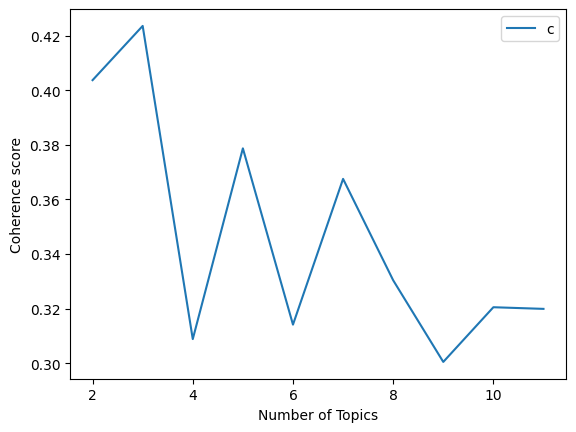

In [22]:
plt.plot(range(min_topics, max_topic + 1), coherence_values)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence score")
plt.legend(("coherence_values"), loc='best')
plt.show()

In [23]:
final_n_topic = 3
lsamodel_f = LsiModel(doc_term, num_topics=final_n_topic, id2word=dictionary)
lsamodel.print_topics()

[(0,
  '0.643*"mr" + 0.441*"said" + 0.196*"trump" + 0.131*"state" + 0.122*"would" + 0.110*"year" + 0.104*"one" + 0.092*"people" + 0.089*"new" + 0.078*"like"'),
 (1,
  '-0.512*"mr" + -0.321*"trump" + 0.311*"said" + 0.269*"saudi" + 0.155*"taliban" + 0.140*"weight" + 0.123*"one" + 0.122*"people" + 0.118*"dr" + 0.116*"afghanistan"')]